# Reintegration readiness — What factors drive integration

## 1. Problem framing

**Business problem.** Case teams want to understand **which intake and placement factors are associated with length of stay** (admission to closure) and to **predict** timelines for planning—without confusing **prediction** with **causal** claims.

**Three distinct tasks (textbook):**

1. **Causal / explanatory (statsmodels OLS).** Goal: interpret **β**, **p-values**, and regression **assumptions** (multicollinearity, residual normality, heteroscedasticity, linearity, autocorrelation). We use **`sm.OLS(...).fit(cov_type="HC3")`**, **`pd.get_dummies(..., drop_first=True)`**, **`sm.add_constant(..., has_constant="add")`**, and **do not** scale dummy variables. Coefficients are read as associations **holding other included variables constant** — **not** as causal effects (observational data, unmeasured confounding).

2. **Predictive — linear (scikit-learn `LinearRegression` in a `Pipeline`).** Goal: **generalization**; metrics are **MAE** and **RMSE** on the **held-out test set** only. Preprocessing (`SimpleImputer`, `StandardScaler` on numerics, `OneHotEncoder(handle_unknown="ignore")` on categoricals) is **fit only on training data** inside the pipeline.

3. **Predictive — nonlinear (scikit-learn `DecisionTreeRegressor`).** Same preprocessing pipeline; tree captures **nonlinearities** and **implicit interactions**. **Feature importance (MDI)** describes **splitting contribution**, **not** causal effects and **not** the same as OLS coefficients.

**Data.** `residents.csv`, `safehouses.csv` in `lighthouse_csv_v7/`. Run from `ml-pipelines/`. Only **~30** closed cases with both dates — results are **illustrative**.


## 2. Data acquisition, preparation & exploration

We merge **safehouse** context by `safehouse_id`. **`capacity_girls`** and **`current_occupancy`** are used **only** to build **`occupancy_ratio`** (avoids multicollinearity among occupancy features in OLS).

### Target

`days_to_closure = (date_closed - date_of_admission).days` for rows with both dates.

### Feature handling (by model type)

- **Causal OLS:** Categorical columns → **`pd.get_dummies(..., drop_first=True)`** (reference category dropped). Numeric columns stay in **natural units** (we **do not** standardize dummies). Boolean/int flags as **0/1**.
- **Predictive sklearn:** `ColumnTransformer`: median imputation + **`StandardScaler`** for numerics; most-frequent imputation + **`OneHotEncoder(handle_unknown="ignore")`** for categoricals (full rank encoding is acceptable for **prediction**).

### Engineered features

`family_risk_flag_count`, `total_vulnerability_score`, `risk_ordinal`, `occupancy_bucket`, and string interactions `reintegration_x_risk`, `case_x_occ_bucket` support **predictive** models. **OLS** uses **`region`, `case_category`, `initial_risk_level`** as categoricals (with `drop_first=True`) plus the **numeric** block so the **train** design stays **full rank** with ~24 rows; other categoricals remain in **sklearn** only.

### Explanatory target transform (OLS only)

Closure time is **right-skewed**. Following **Ch. 10** (residual normality), the **OLS** dependent variable is **`log1p(days_to_closure)`** on the **training** split. **Sklearn** models use **raw days** so **MAE/RMSE** are in **days**.


In [1]:
import json
import os
import warnings
from datetime import datetime, timezone
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import statsmodels.api as sm
except ImportError as e:
    raise ImportError(
        "This notebook requires statsmodels (OLS, VIF). Install with: pip install statsmodels"
    ) from e

from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=UserWarning)

import importlib
import sys
_fn_root = Path.cwd()
if not (_fn_root / "function.py").is_file():
    _fn_root = Path.cwd() / "ml-pipelines"
if (_fn_root / "function.py").is_file():
    _r = str(_fn_root.resolve())
    if _r not in sys.path:
        sys.path.insert(0, _r)
import function as fn

importlib.reload(fn)

try:
    from IPython.display import display
except ImportError:
    display = print  # headless / CI

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree

ROOT = Path.cwd()
DATA = ROOT / "lighthouse_csv_v7"
if not DATA.is_dir():
    alt = ROOT / "ml-pipelines" / "lighthouse_csv_v7"
    if alt.is_dir():
        DATA = alt
assert DATA.is_dir(), "Run from ml-pipelines/ (or repo root with ml-pipelines/lighthouse_csv_v7)."

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("Data dir:", DATA.resolve())

Data dir: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/lighthouse_csv_v7


In [2]:
from db_config import USE_DB, engine, text

TRUTHY = {"1", "true", "yes", "t", "y"}
FALSY = {"0", "false", "no", "f", "n"}
BOOL_STRINGS = TRUTHY | FALSY


def load_table(table_name: str, csv_filename: str, parse_dates=None, **kwargs):
    """Load from Azure SQL when USE_DB=True, else CSV under lighthouse_csv_v7."""
    if USE_DB:
        df = pd.read_sql_table(table_name, engine)
        date_set = set(parse_dates or [])
        for col in date_set:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")
        for col in df.select_dtypes(include="object").columns:
            if col in date_set:
                continue
            non_null = df[col].notna().sum()
            if non_null == 0:
                continue
            converted = pd.to_numeric(df[col], errors="coerce")
            if converted.notna().sum() == non_null:
                df[col] = converted
                continue
            unique_lower = {str(v).lower() for v in df[col].dropna().unique()}
            if unique_lower <= BOOL_STRINGS:
                df[col] = df[col].map(
                    lambda x: 1 if str(x).lower() in TRUTHY else (0 if pd.notna(x) else pd.NA)
                ).astype("Int64")
        df.columns = [str(c) for c in df.columns]
        df = df.astype({col: object for col in df.select_dtypes(include="string").columns})
        return df
    return pd.read_csv(DATA / csv_filename, parse_dates=parse_dates or [], **kwargs)


RISK_ORDINAL_MAP = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}


def build_reintegration_frame() -> pd.DataFrame:
    """Intake features + target days_to_closure; engineered aggregates and interactions."""
    res = load_table("residents", "residents.csv", parse_dates=["date_of_admission", "date_closed"])
    sh = load_table("safehouses", "safehouses.csv", parse_dates=["open_date"])

    df = res.merge(
        sh[["safehouse_id", "region", "capacity_girls", "current_occupancy"]],
        on="safehouse_id",
        how="left",
    )

    sub_cols = [c for c in df.columns if c.startswith("sub_cat_")]
    df["n_subcategory_flags"] = df[sub_cols].fillna(0).astype(int).sum(axis=1)

    df = df.dropna(subset=["date_of_admission", "date_closed"]).copy()
    df["days_to_closure"] = (df["date_closed"] - df["date_of_admission"]).dt.days
    df = df[df["days_to_closure"] >= 0]

    df["referral_bucket"] = df["referral_source"].fillna("(unknown)").astype(str)
    vc = df["referral_bucket"].value_counts()
    rare = set(vc[vc < 2].index)
    df["referral_bucket"] = df["referral_bucket"].where(~df["referral_bucket"].isin(rare), "(other)")

    cap_den = df["capacity_girls"].replace(0, np.nan)
    df["occupancy_ratio"] = df["current_occupancy"] / cap_den

    bool_cols = [
        "is_pwd",
        "has_special_needs",
        "family_is_4ps",
        "family_solo_parent",
        "family_indigenous",
        "family_parent_pwd",
        "family_informal_settler",
    ]
    for c in bool_cols:
        if c in df.columns:
            df[c] = df[c].fillna(0).astype(int)

    df["family_risk_flag_count"] = df[bool_cols].sum(axis=1)
    df["total_vulnerability_score"] = df["n_subcategory_flags"] + df["family_risk_flag_count"]

    df["risk_ordinal"] = df["initial_risk_level"].map(RISK_ORDINAL_MAP)
    med_r = float(df["risk_ordinal"].median())
    df["risk_ordinal"] = df["risk_ordinal"].fillna(med_r)

    occ = df["occupancy_ratio"].clip(lower=0, upper=2.0)
    try:
        df["occupancy_bucket"] = pd.qcut(
            occ.rank(method="first"), q=3, labels=["low", "medium", "high"], duplicates="drop"
        ).astype(str)
    except (ValueError, TypeError):
        df["occupancy_bucket"] = "medium"

    df["reintegration_x_risk"] = (
        df["reintegration_type"].fillna("(unknown)").astype(str)
        + " × "
        + df["initial_risk_level"].fillna("(unknown)").astype(str)
    )
    df["case_x_occ_bucket"] = (
        df["case_category"].fillna("(unknown)").astype(str)
        + " | "
        + df["occupancy_bucket"].astype(str)
    )

    df.columns = [str(c) for c in df.columns]
    df = df.astype({col: object for col in df.select_dtypes(include="string").columns})
    return df


raw = build_reintegration_frame()
print("Modeling rows (closed dates):", len(raw))
print(raw["days_to_closure"].describe())


⚠ No DB connection found — falling back to local CSV files
  Set DB_CONNECTION_STRING env var, or add the connection string to
  backend/Intex2.API/Intex2.API/appsettings.Development.json
Modeling rows (closed dates): 30
count     30.000000
mean     445.100000
std      162.419073
min      191.000000
25%      286.750000
50%      431.000000
75%      583.000000
max      697.000000
Name: days_to_closure, dtype: float64


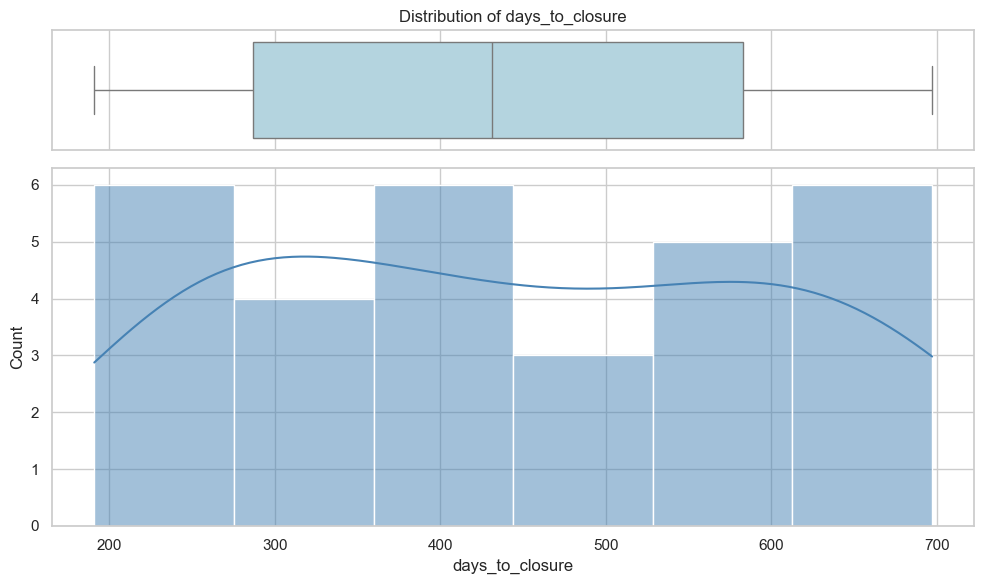

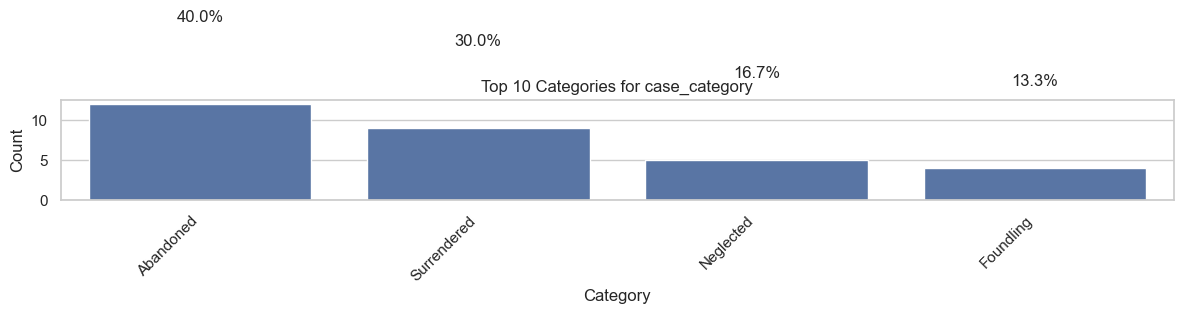

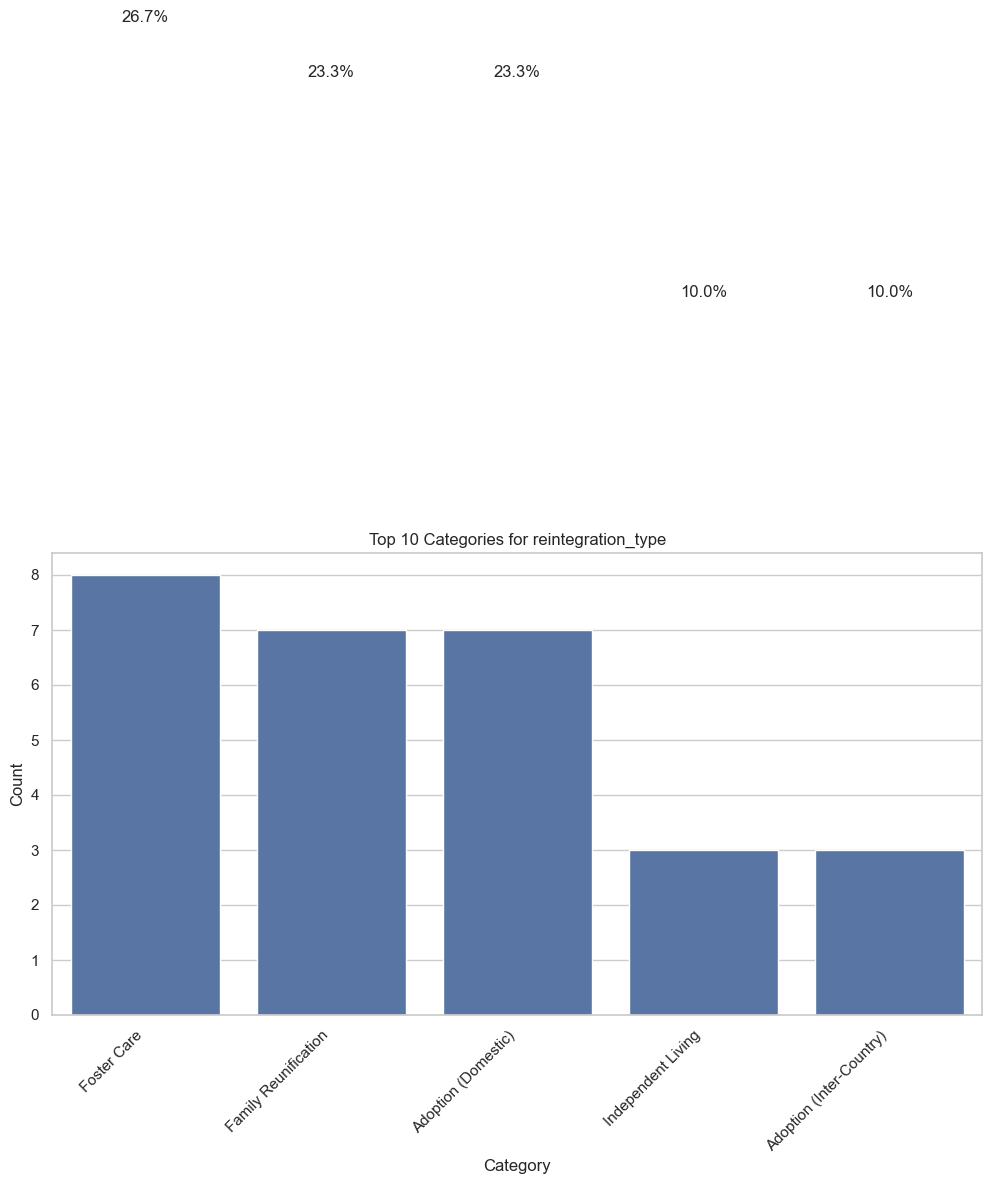

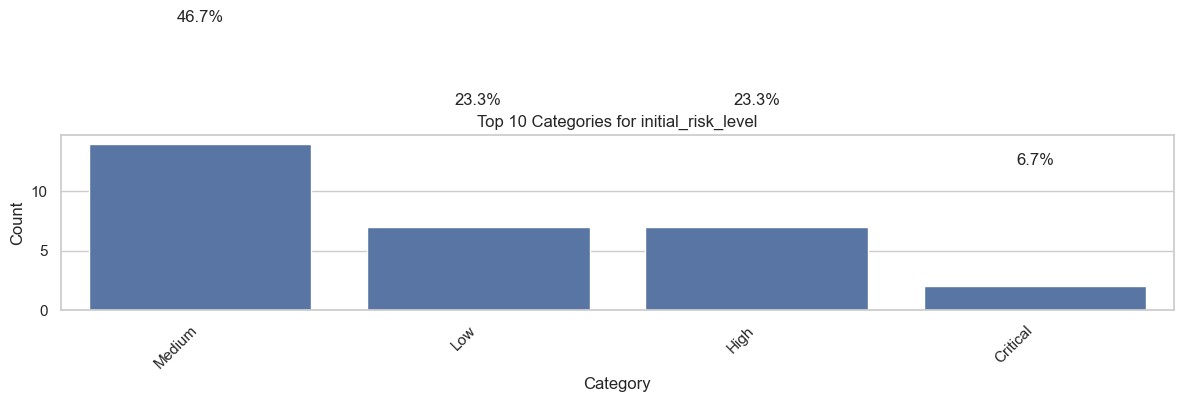

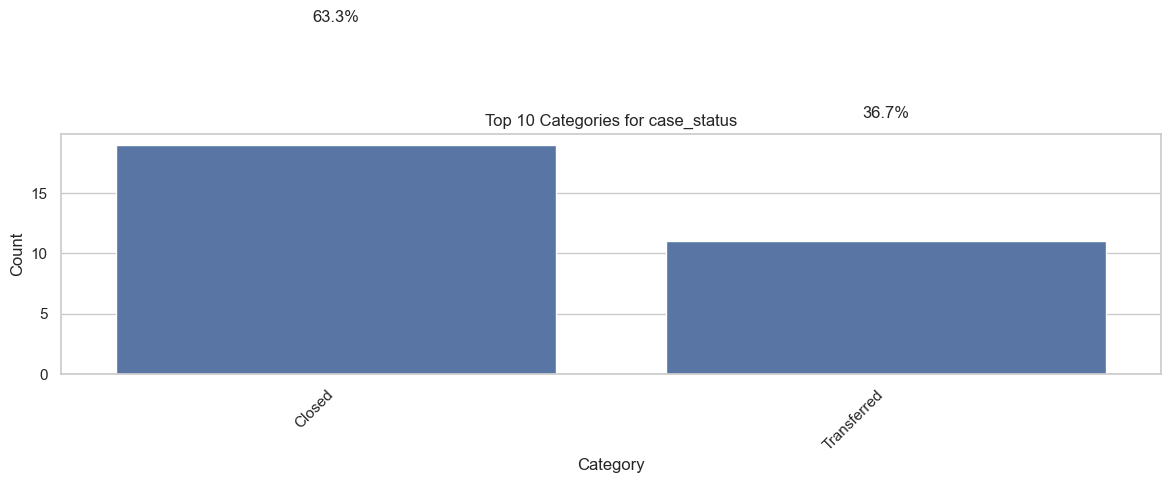

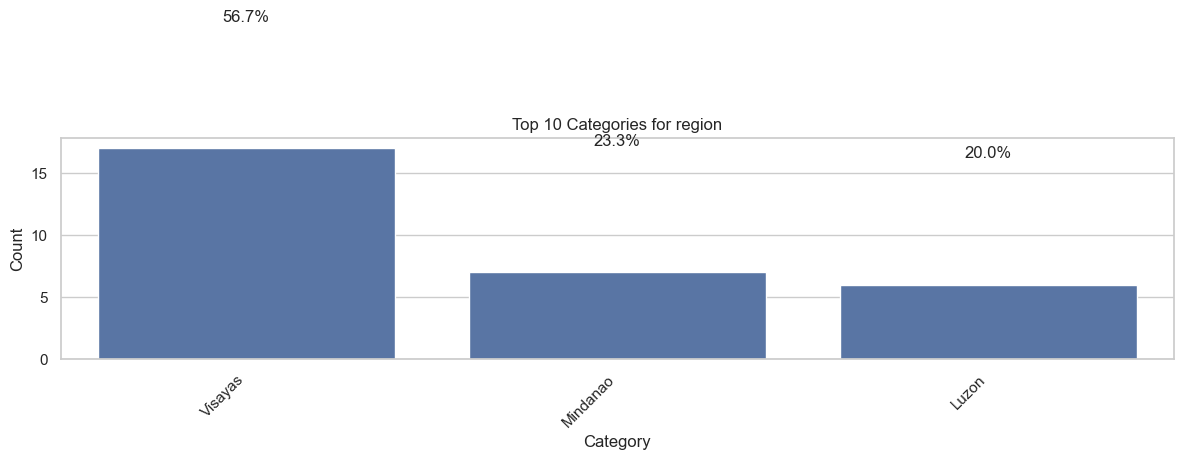

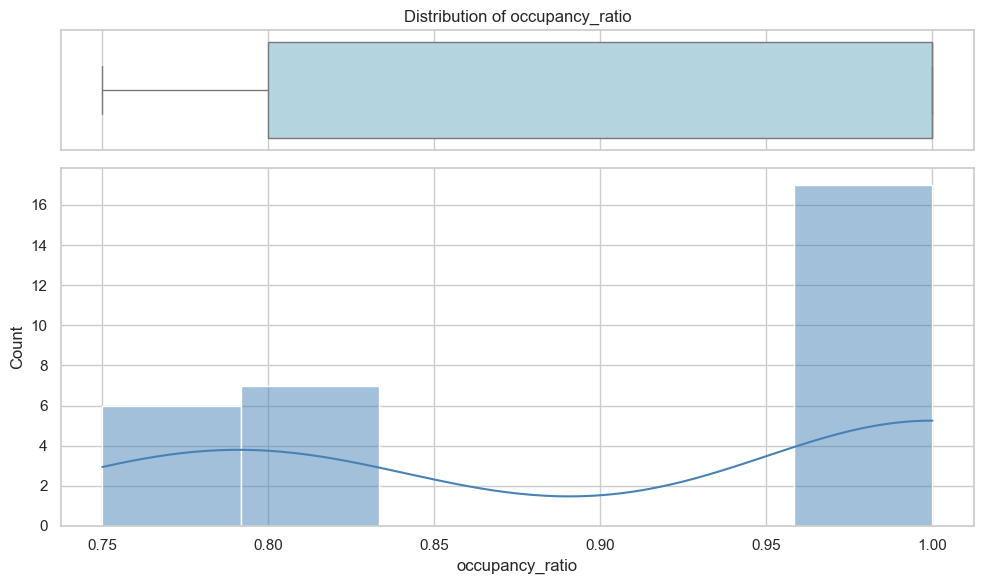

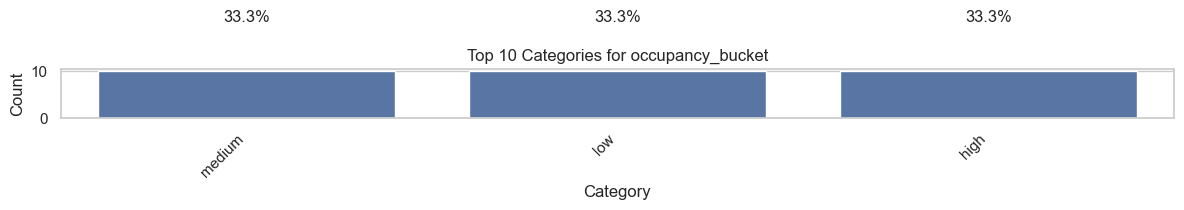

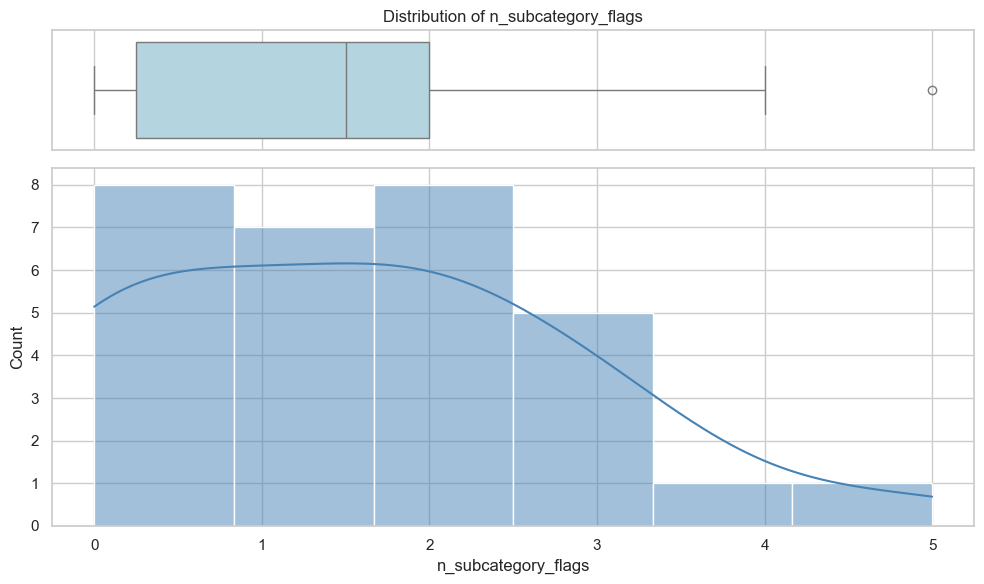

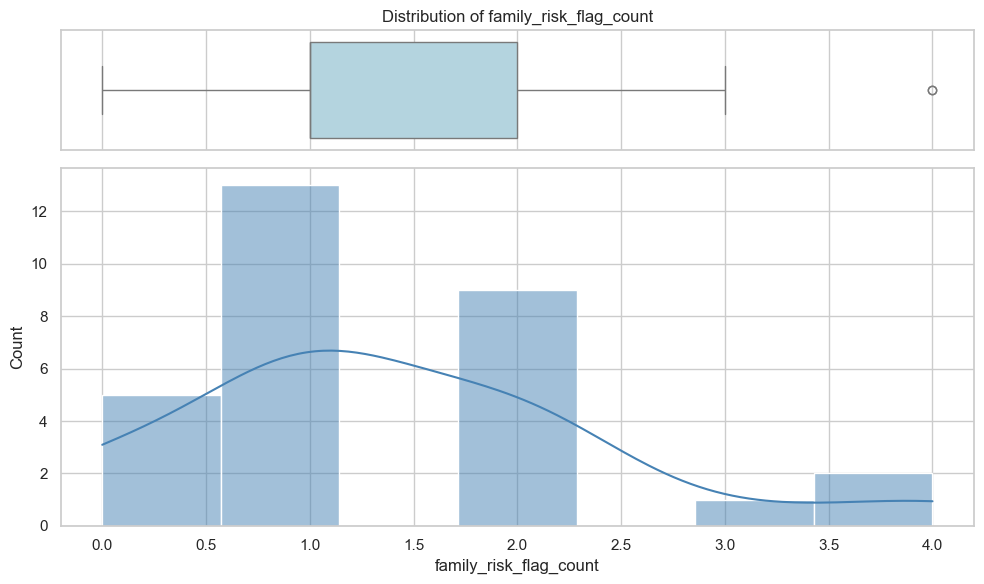

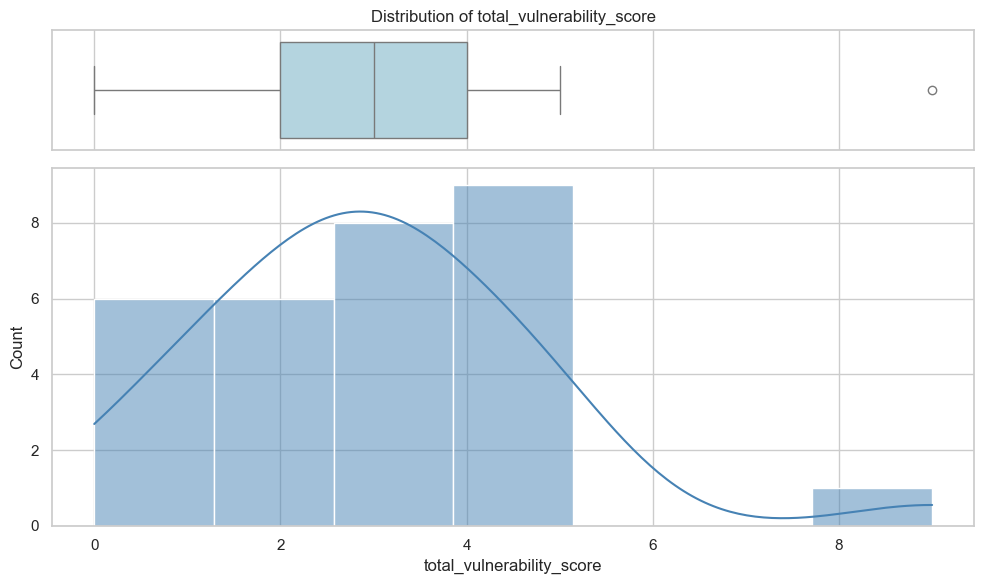

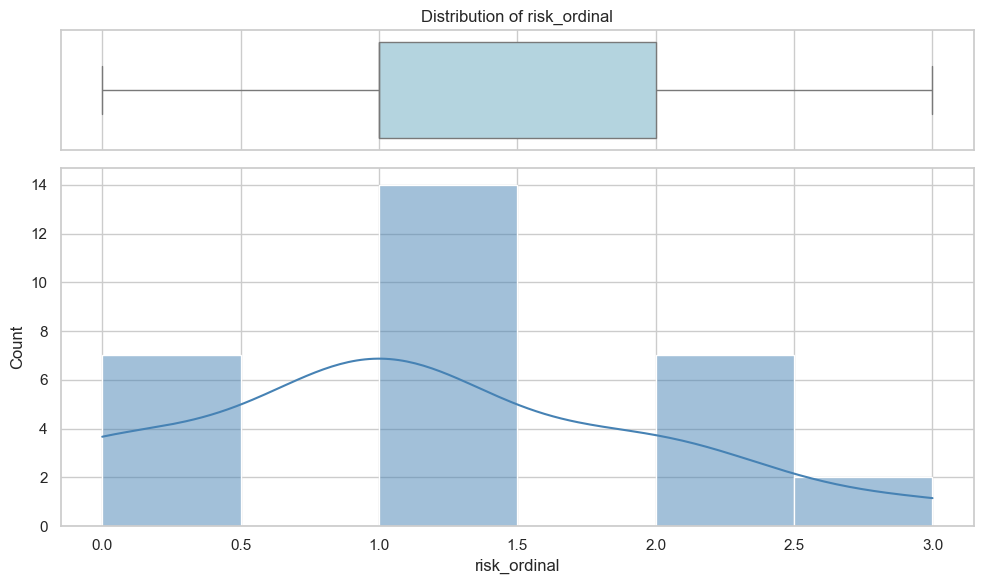

,Data Type,Count,Missing,Unique,Mode,Min,Q1,Median,Q3,Max,Mean,Std,Skew,Kurt
days_to_closure,int64,30,0,30,191,191,286.75,431.0,583.0,697,445.1,162.419073,0.085147,-1.373858
case_category,object,30,0,4,Abandoned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reintegration_type,object,28,2,5,Foster Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
initial_risk_level,object,30,0,4,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
case_status,object,30,0,2,Closed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,object,30,0,3,Visayas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupancy_ratio,float64,30,0,5,1.0,0.75,0.8,1.0,1.0,1.0,0.909175,0.106359,-0.327105,-1.966047
occupancy_bucket,object,30,0,3,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_subcategory_flags,int64,30,0,6,0,0,0.25,1.5,2.0,5,1.566667,1.330889,0.598971,-0.034037
family_risk_flag_count,int64,30,0,5,1,0,1.0,1.0,2.0,4,1.4,1.037238,0.881992,1.0112


In [3]:
explore_cols = [
    "days_to_closure",
    "case_category",
    "reintegration_type",
    "initial_risk_level",
    "case_status",
    "region",
    "occupancy_ratio",
    "occupancy_bucket",
    "n_subcategory_flags",
    "family_risk_flag_count",
    "total_vulnerability_score",
    "risk_ordinal",
]
uni = fn.univariate(raw[explore_cols].copy())
display(uni)

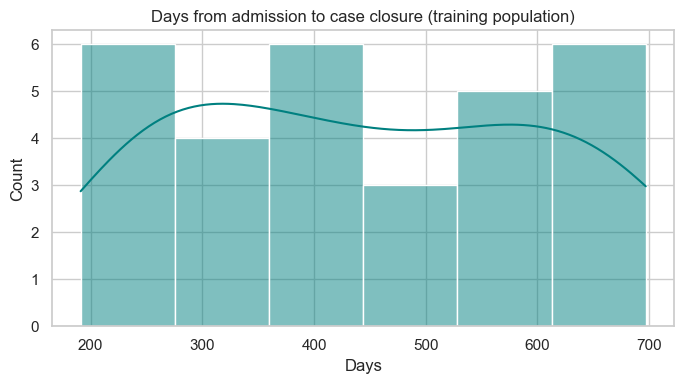

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(raw["days_to_closure"], kde=True, ax=ax, color="teal")
ax.set_title("Days from admission to case closure (training population)")
ax.set_xlabel("Days")
plt.tight_layout()
plt.show()

**Exploration notes.** The target is right-skewed (some long stays). Closed and transferred cases with closure dates share this frame; read OLS and tree results as **associations in historical synthetic data**, not guarantees for future cases.

## 3. Models (strict separation)

### 3a. Causal / explanatory — OLS (statsmodels)

- **Design:** Training rows only; **numeric** predictors in raw units + **dummy** coding with **`drop_first=True`**; **`sm.add_constant(..., has_constant="add")`**; **`fit(cov_type="HC3")`** for heteroscedasticity-robust inference.
- **Diagnostics:** **VIF** (variance inflation factor), **Omnibus / Jarque-Bera** and **Durbin-Watson** from `summary()`, **residual vs fitted** plot for **linearity / heteroscedasticity** (visual).
- **Interpretation:** Sign, magnitude, and significance of **β** on **`log1p(days)`** — **correlation ≠ causation**.

### 3b. Predictive — scikit-learn

- **`train_test_split(..., test_size=0.2, random_state=42)`**.
- **`Pipeline` + `ColumnTransformer`**: imputation and scaling **fit on train only**.
- **Linear regression** and **decision tree** share the same preprocessor; **tree** hyperparameters tuned only on **`max_depth`** and **`min_samples_leaf`** (modest grid; avoid over-tuning).


In [5]:
feature_cols = [
    "safehouse_id",
    "region",
    "occupancy_ratio",
    "occupancy_bucket",
    "case_category",
    "initial_risk_level",
    "case_status",
    "sex",
    "referral_bucket",
    "n_subcategory_flags",
    "family_risk_flag_count",
    "total_vulnerability_score",
    "risk_ordinal",
    "case_x_occ_bucket",
]

X = raw[feature_cols].copy()
y_days = raw["days_to_closure"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_days,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

numeric_features = [
    "safehouse_id",
    "occupancy_ratio",
    "n_subcategory_flags",
    "family_risk_flag_count",
    "total_vulnerability_score",
    "risk_ordinal",
]
categorical_features = [c for c in feature_cols if c not in numeric_features]

numeric_prep = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_prep = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_prep, numeric_features),
        ("cat", categorical_prep, categorical_features),
    ]
)

# ---------- 3a. Explanatory OLS (statsmodels) — train rows only ----------
OLS_NUM = [
    "occupancy_ratio",
    "n_subcategory_flags",
    "risk_ordinal",
    "total_vulnerability_score",
    "family_risk_flag_count",
]
# Keep OLS categoricals limited so the train design stays full-rank with small n.
OLS_CAT = ["region", "case_category", "initial_risk_level"]

def build_ols_design(x_df: pd.DataFrame) -> pd.DataFrame:
    block = x_df[OLS_NUM + OLS_CAT].copy()
    for c in OLS_NUM:
        block[c] = pd.to_numeric(block[c], errors="coerce")
    for c in OLS_CAT:
        block[c] = block[c].astype(str)
    dummies = pd.get_dummies(block, columns=OLS_CAT, drop_first=True)
    for col in dummies.select_dtypes(include=[bool]).columns:
        dummies[col] = dummies[col].astype(int)
    dummies = dummies.astype(float)
    # Drop degenerate columns (e.g. constant dummies) to avoid singular X with HC3.
    dummies = dummies.loc[:, dummies.std(ddof=0) > 1e-12]
    return dummies


X_ols_tr_raw = build_ols_design(X_train)
X_ols_te_raw = build_ols_design(X_test)
X_ols_te_raw = X_ols_te_raw.reindex(columns=X_ols_tr_raw.columns, fill_value=0.0)

y_train_log = np.log1p(y_train.astype(float))

X_ols_tr = sm.add_constant(X_ols_tr_raw, has_constant="add")
X_ols_te_const = sm.add_constant(X_ols_te_raw, has_constant="add")

ols_res = sm.OLS(y_train_log, X_ols_tr).fit(cov_type="HC3")
print(ols_res.summary())

Xvif = X_ols_tr.drop(columns=["const"]).astype(float)
vif_data = []
for i, col in enumerate(Xvif.columns):
    vif_data.append({"term": col, "VIF": float(variance_inflation_factor(Xvif.values, i))})
vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)
print("\nVIF (OLS design, intercept excluded; VIF > 10 suggests problematic multicollinearity):")
display(vif_df)

# Residuals vs fitted (linearity / heteroscedasticity — visual; HC3 addresses SE)
fitted_tr = ols_res.fittedvalues
resid_tr = ols_res.resid

# ---------- 3b. Predictive — LinearRegression ----------
lr_pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        ("lr", LinearRegression()),
    ]
)
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
lr_mae_te = mean_absolute_error(y_test, y_pred_lr)
lr_rmse_te = mean_squared_error(y_test, y_pred_lr) ** 0.5
lr_r2_te = r2_score(y_test, y_pred_lr)
print(
    f"\n--- LinearRegression (test only) — MAE: {lr_mae_te:.1f} days | RMSE: {lr_rmse_te:.1f} days | R²: {lr_r2_te:.3f}"
)

# ---------- 3c. Predictive — DecisionTreeRegressor ----------
tree_pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        (
            "tree",
            DecisionTreeRegressor(random_state=RANDOM_STATE),
        ),
    ]
)
param_grid = {
    "tree__max_depth": [2, 3, 4, 5, None],
    "tree__min_samples_leaf": [2, 3, 5, 8],
}
gs = GridSearchCV(
    tree_pipe,
    param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_mean_absolute_error",
    n_jobs=1,
    refit=True,
)
gs.fit(X_train, y_train)
tree_pipe = gs.best_estimator_
best_depth = gs.best_params_["tree__max_depth"]
best_leaf = gs.best_params_["tree__min_samples_leaf"]
cv_mae_best = float(-gs.best_score_)

print("\n--- DecisionTreeRegressor (CV MAE on train, raw days) ---")
print("Best params:", gs.best_params_)
print("CV MAE (5-fold, train):", cv_mae_best)
print("Train n:", len(X_train), "| Test n:", len(X_test))


                            OLS Regression Results                            
Dep. Variable:        days_to_closure   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                 -0.371
Method:                 Least Squares   F-statistic:                     473.3
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           4.02e-14
Time:                        22:53:40   Log-Likelihood:                -9.0687
No. Observations:                  24   AIC:                             42.14
Df Residuals:                      12   BIC:                             56.27
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

/Users/joshuagoates/miniconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,term,VIF
1,n_subcategory_flags,inf
3,total_vulnerability_score,inf
4,family_risk_flag_count,inf
12,initial_risk_level_Medium,97.467028
11,initial_risk_level_Low,55.530751
2,risk_ordinal,28.047666
10,initial_risk_level_High,16.717172
6,region_Visayas,4.563572
5,region_Mindanao,3.620402
9,case_category_Surrendered,2.472414



--- LinearRegression (test only) — MAE: 2207.7 days | RMSE: 2618.3 days | R²: -798.098

--- DecisionTreeRegressor (CV MAE on train, raw days) ---
Best params: {'tree__max_depth': 2, 'tree__min_samples_leaf': 8}
CV MAE (5-fold, train): 173.37968434343438
Train n: 24 | Test n: 6


## 4. Evaluation (predictive) & OLS diagnostics (explanatory)

- **LinearRegression** and **decision tree:** **MAE** and **RMSE** are computed on the **test set** only (raw **days**).
- **OLS:** Do **not** treat test-set prediction error as the success criterion for **explanatory** modeling; rely on **coefficients**, **robust SEs**, **VIF**, **residual plots**, and **Omnibus / JB / Durbin-Watson** on the **training** fit. **OLS test predictions** are **not** interpreted as causal validation.


--- Decision tree — test set (days) ---
Test MAE:  107.9 days
Test RMSE: 121.0 days
Test R²:   -0.707


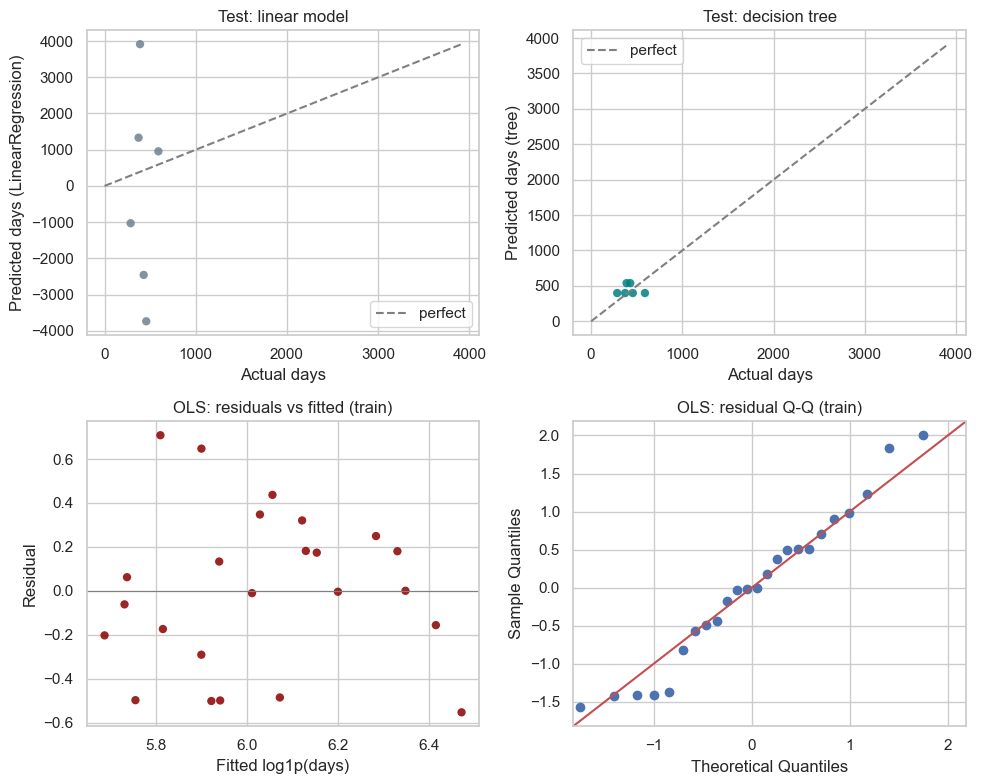


Comparison (test): Linear MAE=2207.7, Tree MAE=107.9 days


In [6]:
y_pred_tree = tree_pipe.predict(X_test)
tree_mae_te = mean_absolute_error(y_test, y_pred_tree)
tree_rmse_te = mean_squared_error(y_test, y_pred_tree) ** 0.5
tree_r2_te = r2_score(y_test, y_pred_tree)

print("--- Decision tree — test set (days) ---")
print(f"Test MAE:  {tree_mae_te:.1f} days")
print(f"Test RMSE: {tree_rmse_te:.1f} days")
print(f"Test R²:   {tree_r2_te:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

lim = max(float(y_test.max()), float(np.max(y_pred_tree)), float(np.max(y_pred_lr)), 1.0)
axes[0, 0].scatter(y_test, y_pred_lr, alpha=0.85, edgecolors="none", color="slategray")
axes[0, 0].plot([0, lim], [0, lim], ls="--", c="gray", label="perfect")
axes[0, 0].set_xlabel("Actual days")
axes[0, 0].set_ylabel("Predicted days (LinearRegression)")
axes[0, 0].set_title("Test: linear model")
axes[0, 0].legend()

axes[0, 1].scatter(y_test, y_pred_tree, alpha=0.85, edgecolors="none", color="teal")
axes[0, 1].plot([0, lim], [0, lim], ls="--", c="gray", label="perfect")
axes[0, 1].set_xlabel("Actual days")
axes[0, 1].set_ylabel("Predicted days (tree)")
axes[0, 1].set_title("Test: decision tree")
axes[0, 1].legend()

axes[1, 0].scatter(fitted_tr, resid_tr, alpha=0.85, edgecolors="none", color="darkred")
axes[1, 0].axhline(0, color="gray", lw=0.8)
axes[1, 0].set_xlabel("Fitted log1p(days)")
axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_title("OLS: residuals vs fitted (train)")

qqplot(resid_tr, line="45", fit=True, ax=axes[1, 1])
axes[1, 1].set_title("OLS: residual Q-Q (train)")

plt.tight_layout()
plt.show()

print(
    f"\nComparison (test): Linear MAE={lr_mae_te:.1f}, Tree MAE={tree_mae_te:.1f} days"
)


### Segmentation check (heterogeneity)

A **single global** model can **average** incompatible subgroups. With only **~30** closures, we **do not** fit separate models per segment (most strata would be empty). Instead we **tabulate** mean/median days by `case_category`, `initial_risk_level`, and `reintegration_type` to show **where** timelines differ descriptively. **Not** causal—case mix and placement rules confound these contrasts.

In [7]:
seg_cols = ["case_category", "initial_risk_level", "reintegration_type"]
for col in seg_cols:
    g = (
        raw.groupby(col, dropna=False)["days_to_closure"]
        .agg(n="count", mean_days="mean", median_days="median")
        .reset_index()
        .sort_values("n", ascending=False)
    )
    print(f"\n--- Days to closure by {col} ---")
    display(g)

MIN_SEG = 8
print(
    f"\n(Separate OLS/tree per segment skipped unless n≥{MIN_SEG} per group; increase closures to enable.)"
)


--- Days to closure by case_category ---


,case_category,n,mean_days,median_days
0,Abandoned,12,424.000000,415.0
3,Surrendered,9,469.333333,490.0
2,Neglected,5,488.800000,433.0
1,Foundling,4,399.250000,359.0



--- Days to closure by initial_risk_level ---


,initial_risk_level,n,mean_days,median_days
3,Medium,14,433.071429,400.0
1,High,7,434.571429,550.0
2,Low,7,460.000000,403.0
0,Critical,2,514.000000,514.0



--- Days to closure by reintegration_type ---


,reintegration_type,n,mean_days,median_days
3,Foster Care,8,416.875000,411.0
0,Adoption (Domestic),7,491.714286,550.0
2,Family Reunification,7,418.571429,371.0
1,Adoption (Inter-Country),3,278.333333,281.0
4,Independent Living,3,645.000000,677.0
5,NaN,2,438.000000,438.0



(Separate OLS/tree per segment skipped unless n≥8 per group; increase closures to enable.)


## 5. Comparison: linear vs tree vs OLS (explanatory)

| Lens | Tool | What to read |
|------|------|----------------|
| **Explanatory** | OLS + HC3 | **β**, **p-values**, **VIF**, **residuals**; “holding other regressors constant” on **`log1p(days)`** |
| **Predictive (linear)** | `LinearRegression` pipeline | **Test MAE / RMSE** |
| **Predictive (nonlinear)** | `DecisionTreeRegressor` | **Test MAE / RMSE**, **CV MAE**, **MDI importance** (no sign / not causal) |

**Stability vs flexibility:** The linear pipeline assumes an approximate **hyperplane** in engineered feature space; the tree **segments** the space and can fit **interactions** without explicit terms. With **small *n***, both can **overfit**; the tree is **regularized** via **`max_depth`** and **`min_samples_leaf`** only.

---

## 6. Causal / relationship analysis (careful language)

**Key drivers (OLS):** Use **sign** and **significance** of coefficients on **`log1p(days)`**; large **VIF** flags unstable **joint** estimation. **Correlation ≠ causation**; omitted variables (courts, family cooperation, policy) can confound associations.

**Tree importance:** **MDI** ranks features by **impurity reduction** in splits — useful for **prediction** and **description**, **not** for **counterfactual** or **policy** causal claims.

**Limitations:** Tiny sample, synthetic/operational data quirks, and **non-experimental** design cap **inferential** strength.


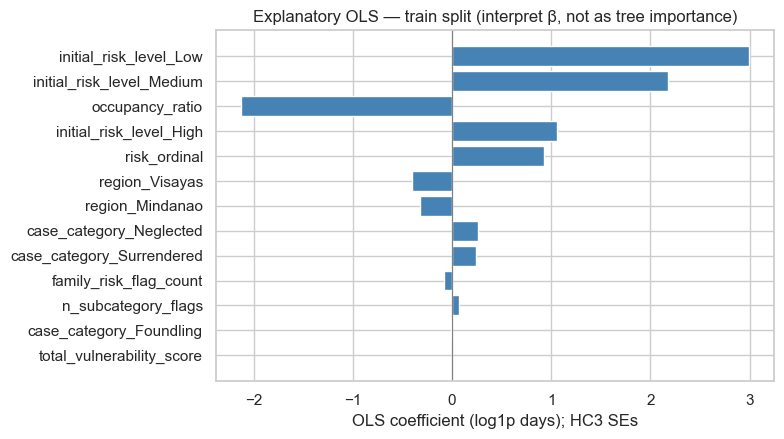

,term,coef,std_err,pvalue,abs_coef
12,initial_risk_level_Low,2.991021,0.779024,0.000123,2.991021
13,initial_risk_level_Medium,2.179015,0.970455,0.024745,2.179015
1,occupancy_ratio,-2.124908,1.989564,0.285508,2.124908
11,initial_risk_level_High,1.062272,0.744056,0.153385,1.062272
3,risk_ordinal,0.923621,0.355970,0.009468,0.923621
7,region_Visayas,-0.403534,0.714497,0.572223,0.403534
6,region_Mindanao,-0.327634,0.804851,0.683953,0.327634
9,case_category_Neglected,0.260006,0.558339,0.641446,0.260006
10,case_category_Surrendered,0.240737,0.558373,0.666366,0.240737
5,family_risk_flag_count,-0.077080,0.225844,0.732881,0.077080


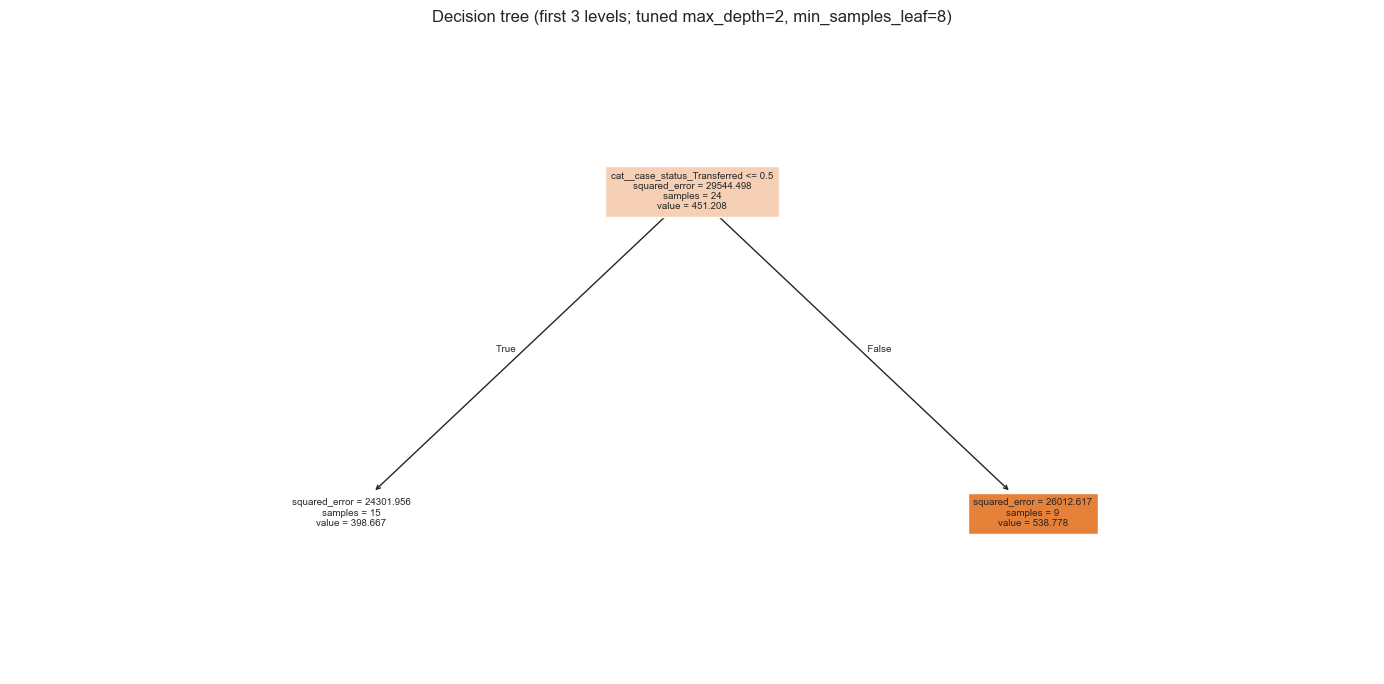

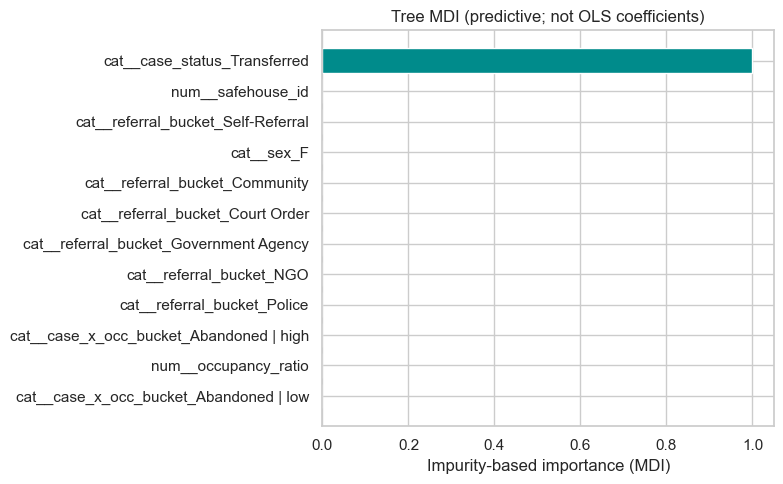

,feature,importance
21,cat__case_status_Transferred,1.0
0,num__safehouse_id,0.0
28,cat__referral_bucket_Self-Referral,0.0
22,cat__sex_F,0.0
23,cat__referral_bucket_Community,0.0
24,cat__referral_bucket_Court Order,0.0
25,cat__referral_bucket_Government Agency,0.0
26,cat__referral_bucket_NGO,0.0
27,cat__referral_bucket_Police,0.0
29,cat__case_x_occ_bucket_Abandoned | high,0.0


In [8]:
# --- Explanatory: OLS coefficients (train; log1p days) — not for prediction benchmarking ---
coef_table = pd.DataFrame(
    {
        "term": ols_res.params.index,
        "coef": ols_res.params.values,
        "std_err": ols_res.bse.values,
        "pvalue": ols_res.pvalues.values,
    }
)
coef_table = coef_table[coef_table["term"] != "const"].copy()
coef_table["abs_coef"] = coef_table["coef"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * min(len(coef_table), 20))))
topc = coef_table.head(20).iloc[::-1]
ax.barh(topc["term"], topc["coef"], color="steelblue")
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("OLS coefficient (log1p days); HC3 SEs")
ax.set_title("Explanatory OLS — train split (interpret β, not as tree importance)")
plt.tight_layout()
plt.show()

display(coef_table.head(20))

# --- Predictive: tree structure & MDI (not causal effects) ---
reg_fitted = tree_pipe.named_steps["tree"]
prep_fitted = tree_pipe.named_steps["prep"]
feat_names = prep_fitted.get_feature_names_out()
imps = reg_fitted.feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": imps}).sort_values(
    "importance", ascending=False
)

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(
    reg_fitted,
    max_depth=3,
    feature_names=feat_names,
    fontsize=7,
    filled=True,
    ax=ax,
)
ax.set_title(
    f"Decision tree (first 3 levels; tuned max_depth={best_depth}, min_samples_leaf={best_leaf})"
)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
topi = imp_df.head(12).iloc[::-1]
ax2.barh(topi["feature"], topi["importance"], color="darkcyan")
ax2.set_xlabel("Impurity-based importance (MDI)")
ax2.set_title("Tree MDI (predictive; not OLS coefficients)")
plt.tight_layout()
plt.show()

display(imp_df.head(15))


## 7. Deployment notes 

**FOR TA:** This pipeline can be found in the Resident information in reports and analytics tab. It shows the top features for reintegration :)

The next cells serialize **`reintegration_timeline_model.joblib`** (tree `Pipeline`), **`reintegration_timeline_metadata.json`**, and a small **`reintegration_drivers_preview.json`** combining OLS and tree summaries.

In [9]:
ART = Path(".")

joblib.dump(tree_pipe, ART / "reintegration_timeline_model.joblib")

drivers_ols = []
for _, row in coef_table.head(15).iterrows():
    drivers_ols.append(
        {
            "term": row["term"],
            "coefficient": float(row["coef"]),
            "robust_se": float(row["std_err"]),
            "pvalue": float(row["pvalue"]),
            "note": "statsmodels OLS on train; log1p(days); HC3; association not causal.",
        }
    )

drivers_tree = []
for _, row in imp_df.head(15).iterrows():
    drivers_tree.append({"feature": row["feature"], "importance": float(row["importance"])})

meta = {
    "primary_saved_model": "sklearn_pipeline_decision_tree_raw_days",
    "ols_spec": "statsmodels_OLS_HC3_get_dummies_drop_first_add_constant_log1p_y_train",
    "target_raw_days": "days_to_closure = date_closed - date_of_admission",
    "ols_dependent": "log1p(days_to_closure) on train split",
    "sklearn_target": "raw days_to_closure",
    "train_test_split": {"test_size": 0.2, "random_state": RANDOM_STATE},
    "n_rows": int(len(raw)),
    "features": feature_cols,
    "ols_train_n": int(len(X_train)),
    "ols_predictor_count_ex_const": int(X_ols_tr.shape[1] - 1),
    "linear_reg_test_mae_days": float(lr_mae_te),
    "linear_reg_test_rmse_days": float(lr_rmse_te),
    "linear_reg_test_r2": float(lr_r2_te),
    "tree_test_mae_days": float(tree_mae_te),
    "tree_test_rmse_days": float(tree_rmse_te),
    "tree_test_r2": float(tree_r2_te),
    "tree_cv_mae_mean_train_days": float(cv_mae_best),
    "tree_best_params": {
        "max_depth": best_depth,
        "min_samples_leaf": best_leaf,
    },
    "ols_r_squared_train": float(ols_res.rsquared),
    "trained_at": datetime.now(timezone.utc).isoformat(),
}

with open(ART / "reintegration_timeline_metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, default=str)

payload = {
    "pipeline": "reintegration-readiness",
    "target_raw_days": "days_to_closure",
    "sklearn_models": "LinearRegression + DecisionTree raw days; test_size=0.2",
    "ols_model": "statsmodels OLS log1p(days) train-only explanatory",
    "n_cases": int(len(raw)),
    "linear_reg_test_metrics": {
        "mae": float(lr_mae_te),
        "rmse": float(lr_rmse_te),
        "r2": float(lr_r2_te),
    },
    "tree_test_metrics": {
        "mae": float(tree_mae_te),
        "rmse": float(tree_rmse_te),
        "r2": float(tree_r2_te),
    },
    "top_ols_terms": drivers_ols,
    "top_tree_importances": drivers_tree,
    "disclaimer": "Associations / MDI are not causal effects.",
}

out_json = ART / "reintegration_drivers_preview.json"
out_json.write_text(json.dumps(payload, indent=2), encoding="utf-8")

print("Wrote:", (ART / "reintegration_timeline_model.joblib").resolve())
print("Wrote:", (ART / "reintegration_timeline_metadata.json").resolve())
print("Wrote:", out_json.resolve())


Wrote: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/reintegration_timeline_model.joblib
Wrote: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/reintegration_timeline_metadata.json
Wrote: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/reintegration_drivers_preview.json


In [10]:
# ── PRODUCTION: Write reintegration drivers to Azure SQL (runs only when USE_DB=True) ──
if USE_DB:
    import datetime as _dt
    _model_version = _dt.date.today().isoformat()
    _now = _dt.datetime.utcnow()

    # OLS top-10 by |coefficient|
    # IMPORTANT: direction is semantically inverted vs raw sign.
    # Positive coef = more days = SLOWER reintegration -> store 'negative' (frontend shows down-arrow slower).
    # Negative coef = fewer days = FASTER reintegration -> store 'positive' (frontend shows up-arrow faster).
    _ols_rows = []
    for _rank, (_, _row) in enumerate(coef_table.head(10).iterrows(), start=1):
        _ols_rows.append({
            'scored_at':     _now,
            'model_type':    'OLS',
            'rank':          _rank,
            'feature_name':  str(_row['term'])[:100],
            'importance':    float(abs(_row['coef'])),
            'direction':     'negative' if _row['coef'] > 0 else 'positive',
            'model_version': _model_version,
            'is_current':    1,
        })

    # Decision tree top-10 by MDI -- no direction
    _tree_rows = []
    for _rank, (_, _row) in enumerate(imp_df.head(10).iterrows(), start=1):
        _tree_rows.append({
            'scored_at':     _now,
            'model_type':    'DecisionTree',
            'rank':          _rank,
            'feature_name':  str(_row['feature'])[:100],
            'importance':    float(_row['importance']),
            'direction':     None,
            'model_version': _model_version,
            'is_current':    1,
        })

    _drivers_df = pd.DataFrame(_ols_rows + _tree_rows)

    with engine.begin() as _conn:
        _conn.execute(text("UPDATE ml_reintegration_drivers SET is_current = 0 WHERE is_current = 1"))
        _drivers_df.to_sql('ml_reintegration_drivers', _conn, if_exists='append', index=False)

    print(f"Wrote {len(_drivers_df)} reintegration driver rows to ml_reintegration_drivers (model v{_model_version})")
else:
    print("Skipping DB write -- USE_DB is False (no DB_CONNECTION_STRING set)")


Skipping DB write -- USE_DB is False (no DB_CONNECTION_STRING set)
